Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded!")

All libraries loaded!


Load data

In [6]:
df = pd.read_csv('netflix1.csv')
print("Dataset shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (8790, 10)

First 3 rows:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"


Check data quality

In [3]:
print("INFO:")
print(df.info())
print("\nMISSING VALUES:")
print(df.isnull().sum())
print("\nDUPLICATES:", df.duplicated().sum())

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None

MISSING VALUES:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

DUPLICATES: 0


Now we clean columns

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Clean column names:")
print(df.columns.tolist())

Clean column names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


Now we find some missing values.

In [5]:
df['director'] = df['director'].fillna('Not Given')
df['country'] = df['country'].fillna('Not Given')
df['rating'] = df['rating'].fillna('Not Rated')

print("Missing values filled!")
print(df.isnull().sum())

Missing values filled!
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


Now we convert data.

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print("Date converted!")
print("Missing dates:", df['date_added'].isnull().sum())

Date converted!
Missing dates: 0


Now we remove some duplicates.

In [7]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Removed {df.duplicated().sum()} duplicates")
else:
    print("No duplicates found")

No duplicates found


In [ ]:
Now we add year.

In [8]:
df['year_added'] = df['date_added'].dt.year
df['days_since_added'] = (pd.Timestamp('2025-12-19') - df['date_added']).dt.days
print("Features added!")
df[['title', 'year_added', 'days_since_added']].head()

Features added!


,title,year_added,days_since_added
0,Dick Johnson Is Dead,2021,1546
1,Ganglands,2021,1547
2,Midnight Mass,2021,1547
3,Confessions of an Invisible Girl,2021,1549
4,Sankofa,2021,1547


Movies vs Tv shows

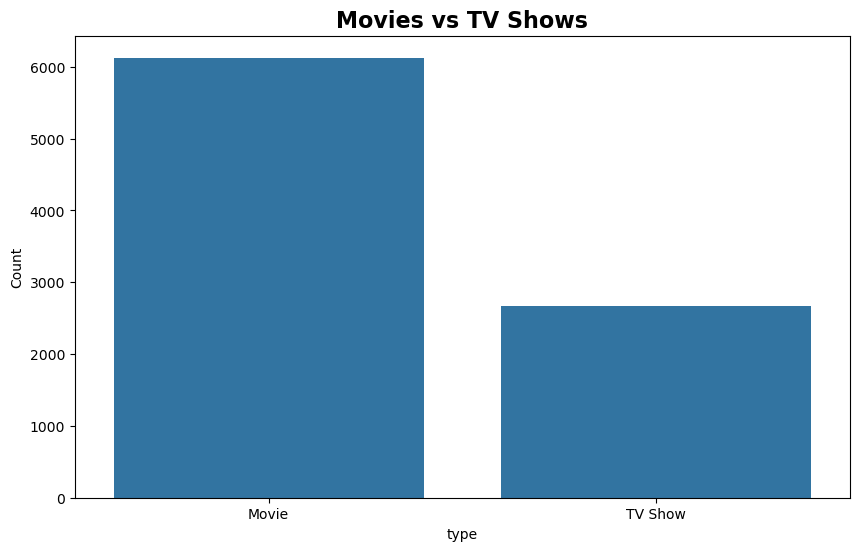

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.savefig('plot1_movies_tv.png', dpi=300)
plt.show()

Top countries 

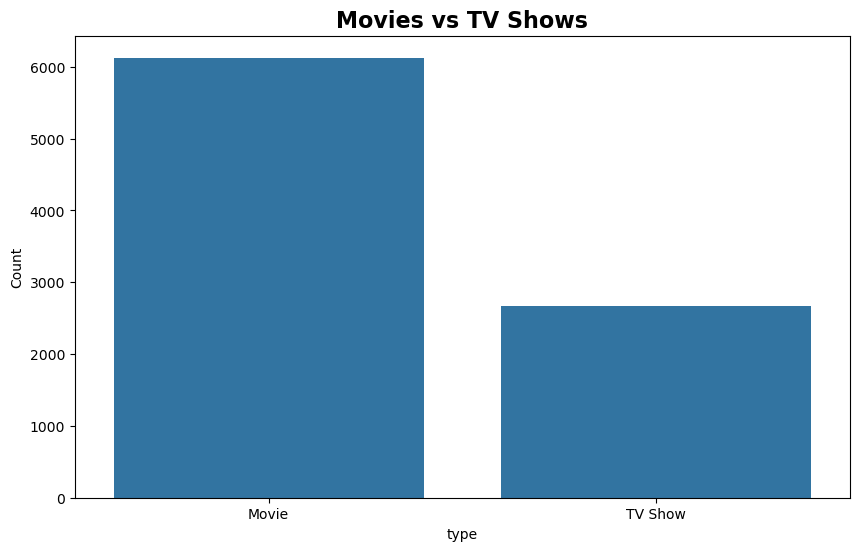

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.savefig('plot1_movies_tv.png', dpi=300)
plt.show()

Ratings

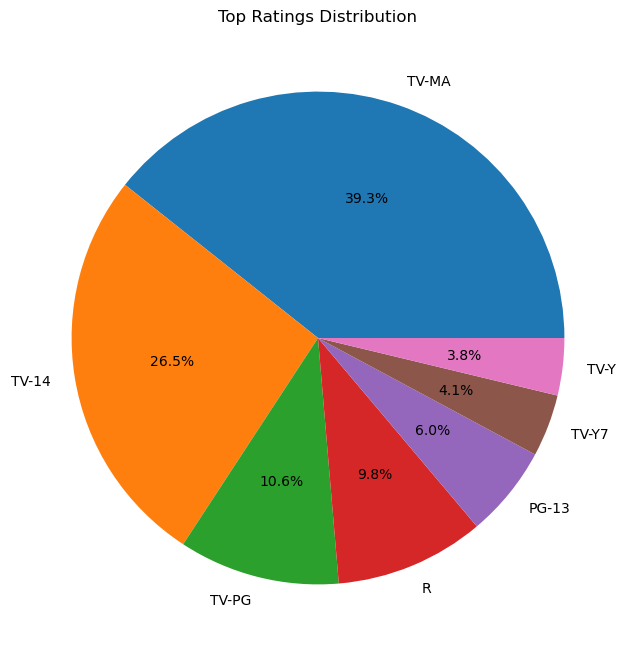

In [11]:
plt.figure(figsize=(8, 8))
top_ratings = df['rating'].value_counts().head(7)
plt.pie(top_ratings.values, labels=top_ratings.index, autopct='%1.1f%%')
plt.title('Top Ratings Distribution')
plt.savefig('plot3_ratings.png', dpi=300)
plt.show()

Content Over years

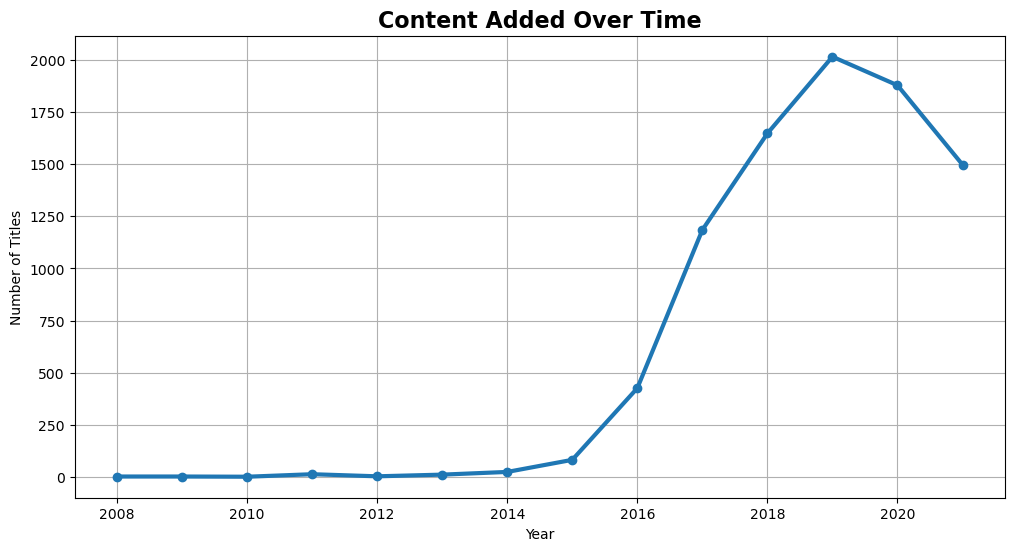

In [12]:
plt.figure(figsize=(12, 6))
yearly = df.groupby('year_added').size()
plt.plot(yearly.index, yearly.values, marker='o', linewidth=3)
plt.title('Content Added Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.savefig('plot4_yearly.png', dpi=300)
plt.show()

Top Genres

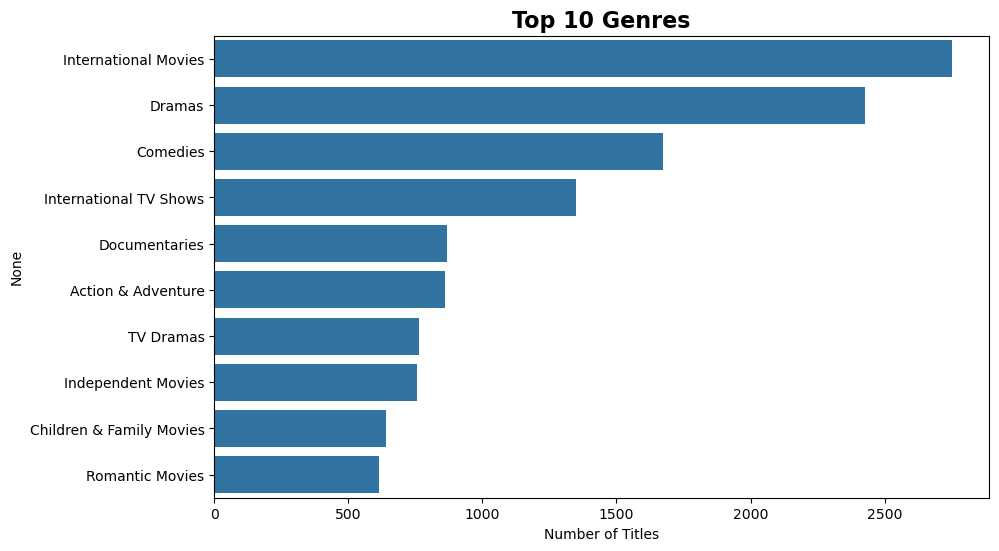

In [13]:
all_genres = []
for genres in df['listed_in']:
    all_genres.extend(genres.split(', '))
    
genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=genre_counts.index, x=genre_counts.values)
plt.title('Top 10 Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.savefig('plot5_genres.png', dpi=300)
plt.show()

Directors

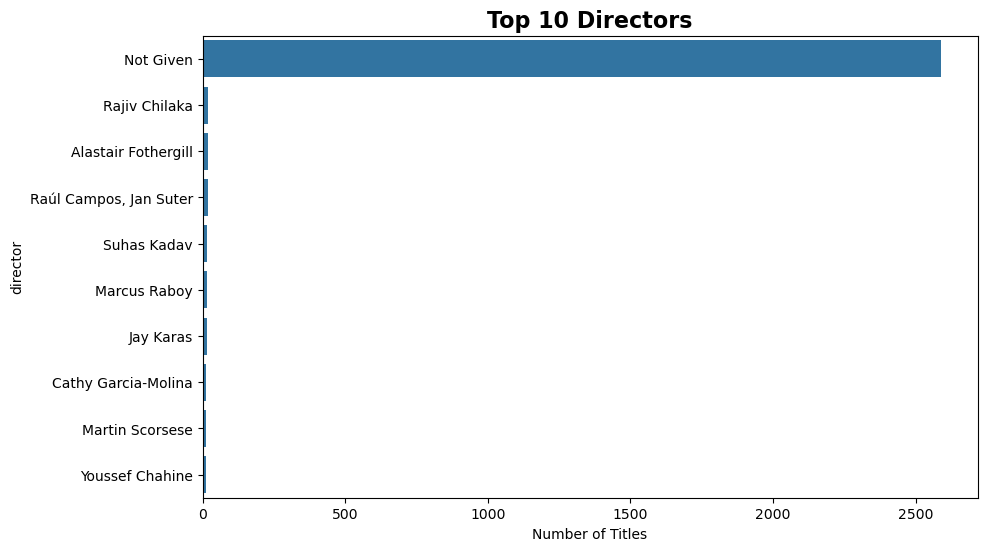

In [14]:
top_directors = df['director'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_directors.index, x=top_directors.values)
plt.title('Top 10 Directors', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.savefig('plot6_directors.png', dpi=300)
plt.show()

Insight section 

In [16]:
print("KEY INSIGHTS:")

type_counts = df['type'].value_counts()
total = len(df)

print(f"1. Total titles: {total:,}")
print(f"2. Movies: {type_counts['Movie']:,} ({type_counts['Movie'] / total * 100:.1f}%)")
print(f"3. Top country: {df['country'].value_counts().index[0]}")
print(f"4. Top genre: {genre_counts.index[0]}")
print(f"5. Peak year: {df['year_added'].mode()[0]}")

KEY INSIGHTS:
1. Total titles: 8,790
2. Movies: 6,126 (69.7%)
3. Top country: United States
4. Top genre: International Movies
5. Peak year: 2019


Save clean data

In [17]:
df.to_csv('netflix_clean_final.csv', index=False)
print("Clean data saved as 'netflix_clean_final.csv'")

Clean data saved as 'netflix_clean_final.csv'


Sample

In [18]:
def simple_recommend(title, top_n=5):
    # Find similar by country, rating, type
    title_row = df[df['title'].str.contains(title, case=False)]
    if title_row.empty:
        return "Title not found!"
    
    recs = df[
        (df['country'] == title_row['country'].iloc[0]) & 
        (df['rating'] == title_row['rating'].iloc[0]) &
        (df['type'] == title_row['type'].iloc[0])
    ].head(top_n)
    
    return recs[['title', 'director', 'country']].head(top_n)

print("Sample Recommendations:")
print(simple_recommend('Dick Johnson'))


Sample Recommendations:
                   title         director        country
0   Dick Johnson Is Dead  Kirsten Johnson  United States
6           The Starling   Theodore Melfi  United States
30             Grown Ups     Dennis Dugan  United States
31            Dark Skies    Scott Stewart  United States
32              Paranoia   Robert Luketic  United States


Final summary

Word cloud

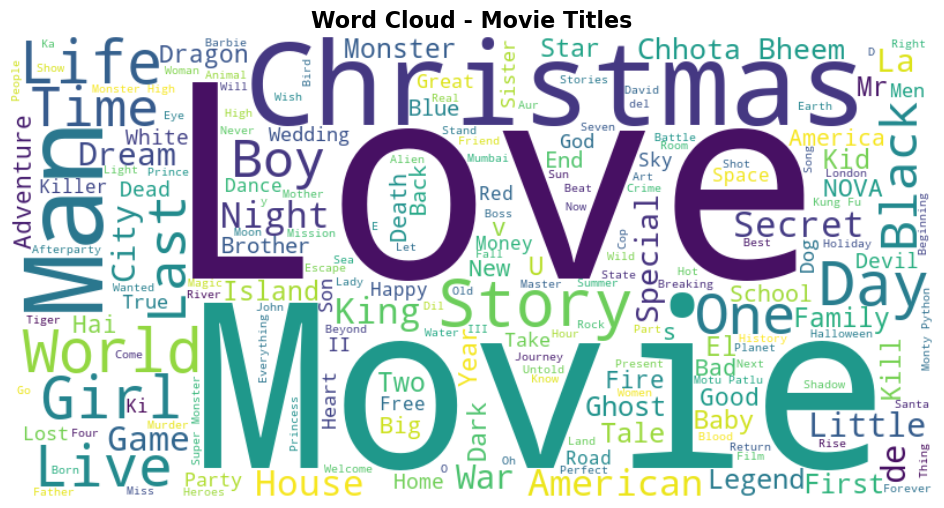

In [20]:
!pip install wordcloud --quiet

from wordcloud import WordCloud

movie_titles = ' '.join(df[df['type']=='Movie']['title'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(movie_titles)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Movie Titles', fontsize=16, fontweight='bold')
plt.savefig('wordcloud_movies.png', dpi=300)
plt.show()